<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/practical_7_activation_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Techniques (DOAI250006)
## Institution: NIELIT ROPAR
## Practical 7: Implementation of ANN using backpropagation with different activation function

This notebook demonstrates how different activation functions (Sigmoid, Tanh, and ReLU) impact the training process of an Artificial Neural Network (ANN) during backpropagation.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Data Loading and Preprocessing
We will use the standard MNIST handwritten digits dataset for this comparison.

In [ ]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0.0 and 1.0
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f'Training data shape: {x_train.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)


### 2. Model Builder Function
To ensure a fair comparison, we create a function that builds the exact same network architecture (one hidden layer with 128 neurons), allowing us to pass the desired activation function as an argument.

In [ ]:
def build_and_train_model(activation_function_name, epochs=10):
    print(f"\n--- Training model with {activation_function_name.upper()} activation ---")

    model = tf.keras.models.Sequential([
      tf.keras.layers.Flatten(input_shape=(28, 28)),
      # This is where we inject the different activation functions
      tf.keras.layers.Dense(128, activation=activation_function_name),
      tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='sgd', # Using Stochastic Gradient Descent for clear backprop observation
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model and store the history
    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        validation_split=0.1,
                        verbose=0) # Set verbose=0 to keep the output clean

    # Evaluate on test set
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Final Test Accuracy ({activation_function_name}): {test_acc:.4f}")

    return history

### 3. Training and Comparison
We will now train three separate models using 'sigmoid', 'tanh', and 'relu', and record their training histories.

In [ ]:
activation_functions = ['sigmoid', 'tanh', 'relu']
histories = {}

for func in activation_functions:
    histories[func] = build_and_train_model(func, epochs=15)


--- Training model with SIGMOID activation ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final Test Accuracy (sigmoid): 0.9200

--- Training model with TANH activation ---
Final Test Accuracy (tanh): 0.9509

--- Training model with RELU activation ---
Final Test Accuracy (relu): 0.9592


### 4. Visualizing the Results
By plotting the validation accuracy over time, we can visualize the vanishing gradient problem (common with Sigmoid in deeper networks, though visible here in slower convergence) versus the faster convergence of ReLU.

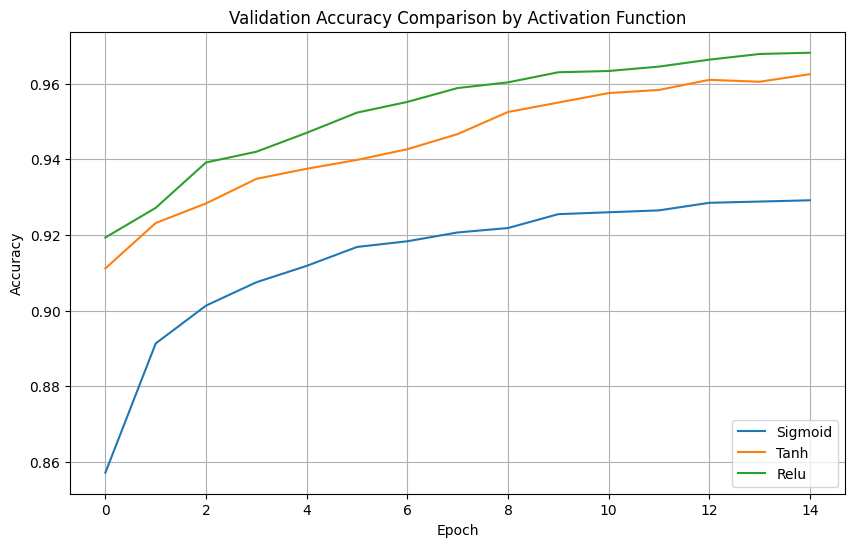

In [ ]:
plt.figure(figsize=(10, 6))

# Plot validation accuracy for each activation function
for func in activation_functions:
    plt.plot(histories[func].history['val_accuracy'], label=func.capitalize())

plt.title('Validation Accuracy Comparison by Activation Function')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()